In [9]:
### IMPORT SCIENTIFIC LIBRARIES ###
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.optimize import curve_fit
import importlib

import matplotlib.pyplot as plt
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18
#%matplotlib widget

import os, sys, importlib, gc
sys.path.append('./XPCS_library/')

import ID10_tools as ID10
from ID10_tools import Nx, Ny, Npx
ID10.set_version('v2')
importlib.reload(ID10)

import XPCS_tools as XPCS
from XPCS_tools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAY_tools as COSMIC
COSMIC.set_beamline('ID10')

# RAW FOLDER PATH
raw_folder = '../RAW_DATA/'
mask_folder = '../masks/'
fit_out_folder = './data/fit_outs/'
Idt_folder = './data/Idts/'
g2_folder = './data/g2/'

# EXPERIMENTAL VARIABLES
XPCS.set_expvar(1350, 1350, 7)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000

## Load masks

In [10]:
e4m_htmask = np.load(mask_folder+'e4m_htmask_copper_foil_30um_1_1'+'.npy')
e4m_mask = np.load(mask_folder+'e4m_mask'+'.npy')

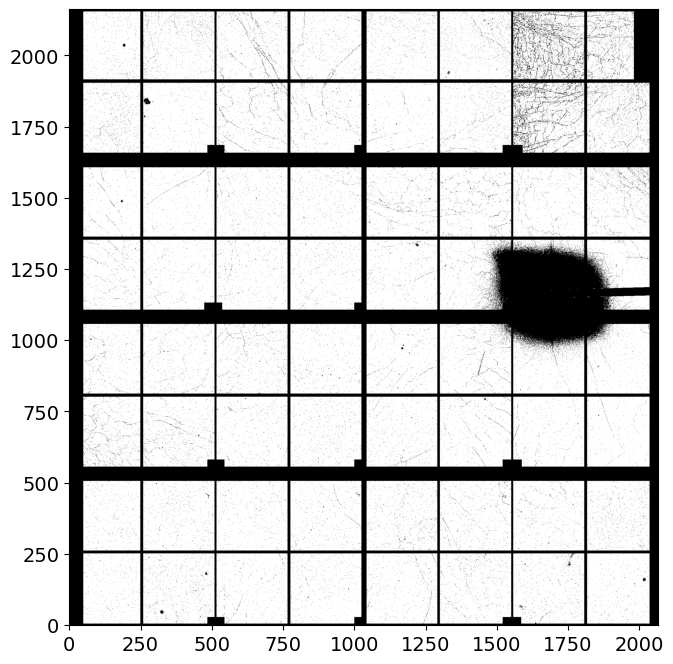

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')

### BS mask and Q definition
Using a random scan in GeO2_6, because we are not changing the measurement configuration

#### Beamstop mask

In [13]:
#######################################
sample_name = 'GeO2_7_30C'
Ndataset = 3
Nscan = 3
Nfi, Nff = 0, 10000
#######################################

scan = ID10.load_scan(raw_folder, sample_name, Ndataset, Nscan)
num_frames = scan['num frames']
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('number of frames =', num_frames)
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(raw_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
number of frames = 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/3 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/3 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/3 loops)
Done! (elapsed time = 0.1 s)
Concatenating vectors ...
Done! (elapsed time = 0.04 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_30C/GeO2_7_30C_0003/scan0003/
	 | Shape:       (10000, 4471016)
	 | Sparsity:     1.6e-04
	 | Memory usage (scipy.csr_array): 0.080 GB (np.array usage: 166.558 GB)


################################################################################
Maximum count in the hull run -> 253.0
# of pixels above Ith_high treshold ->  78 pixels (of 4471016 => 0.0 %)
################################################################################



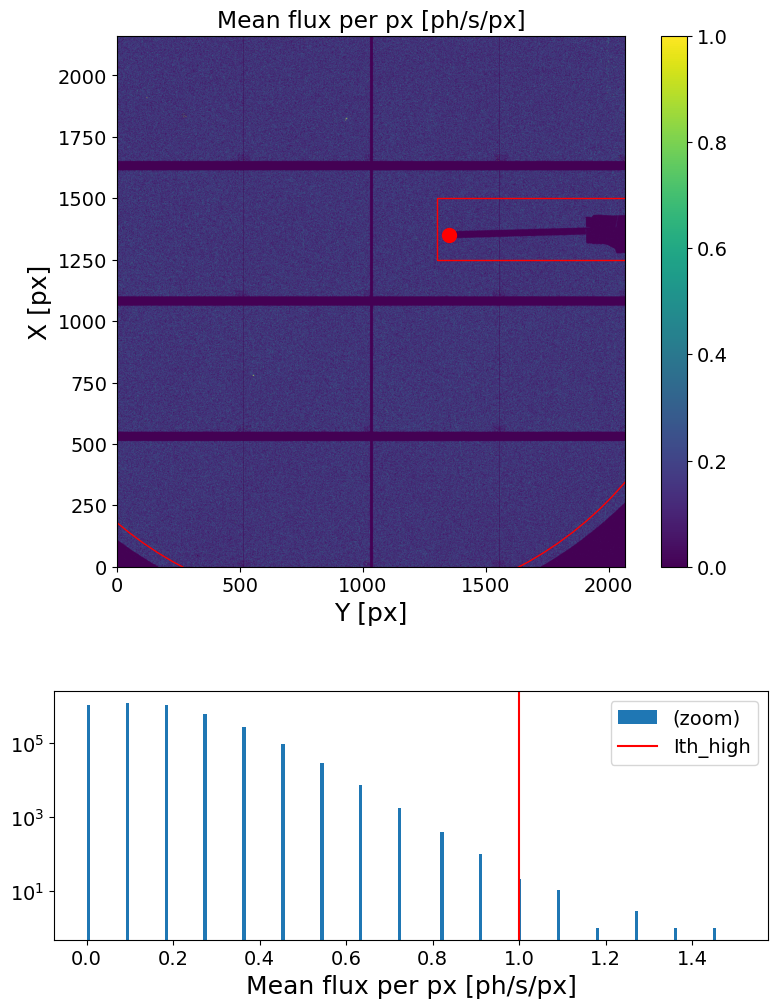

In [14]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=1, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



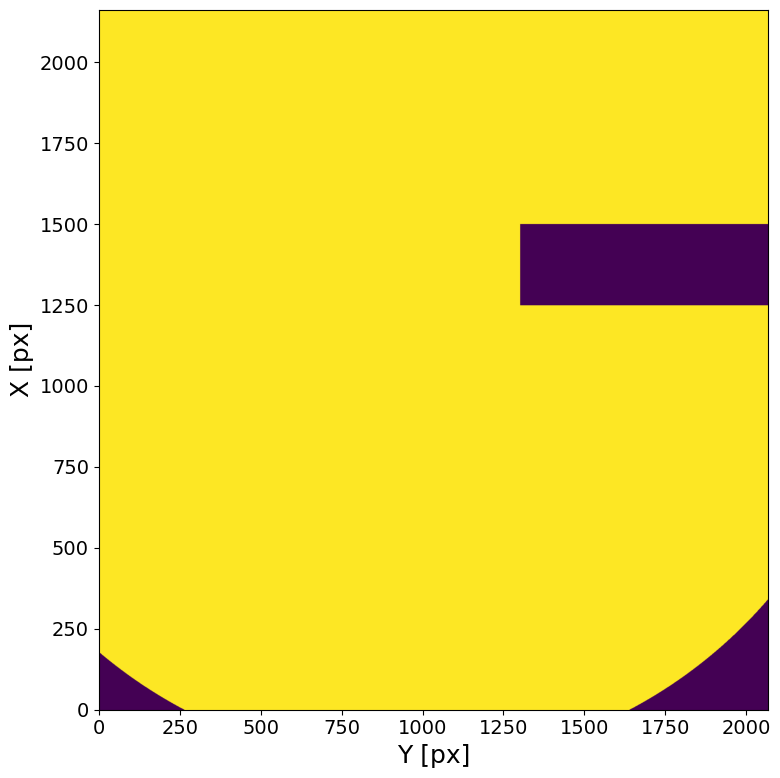

In [15]:
bs_mask = XPCS.gen_mask(e4m_data, itime, mask=None, mask_geom=geom)

#### Q mask

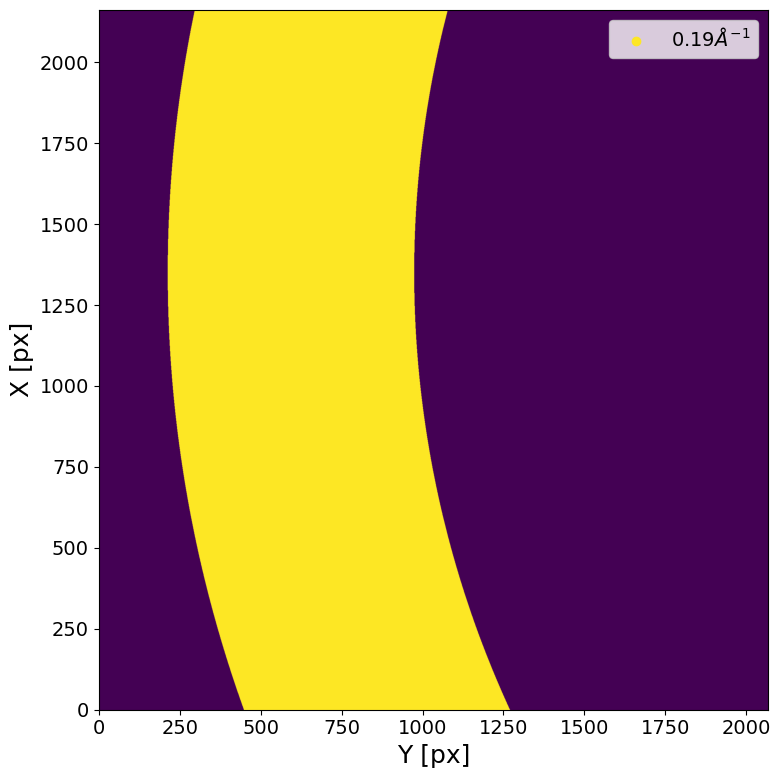

In [16]:
Qmask = XPCS.gen_Qmask(Ei, theta, .19, .02, Qmap_plot=False)

## XPCS scan (T = 30C Q =  0.19 Å, 5 min @ 1ms (300_000 fm)) (GeO2_3_test, dataset 1, scan 1)

In [17]:
#######################################
sample_name = 'GeO2_3_alligment'
Ndataset = 1
Nscan = 6
Nfi, Nff = None, None
load_mask = e4m_mask*e4m_htmask*bs_mask*Qmask
#######################################

scan = ID10.load_scan(raw_folder, sample_name, Ndataset, Nscan)
num_frames = scan['num frames']
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('number of frames =', num_frames)
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(raw_folder, sample_name, Ndataset, Nscan, Nfi, Nff, load_mask=load_mask, n_jobs=60, )
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=5)

#############################
command = mtimescan 0.001 1 300048
number of frames = 300048
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/61 loops)
	 -> loading file	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/61 loops)
 eiger4m_v2_sparse_frame_0_00001.h5 (2/61 loops)
	 -> loading file	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/61 loops)
 eiger4m_v2_sparse_frame_0_00009.h5 (10/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00016.h5 (17/61 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00013.

### Flux check

################################################################################
Maximum count in the hull run -> 5.0
# of pixels above Ith_high treshold ->  3046020 pixels (of 4471016 => 68.13 %)
################################################################################



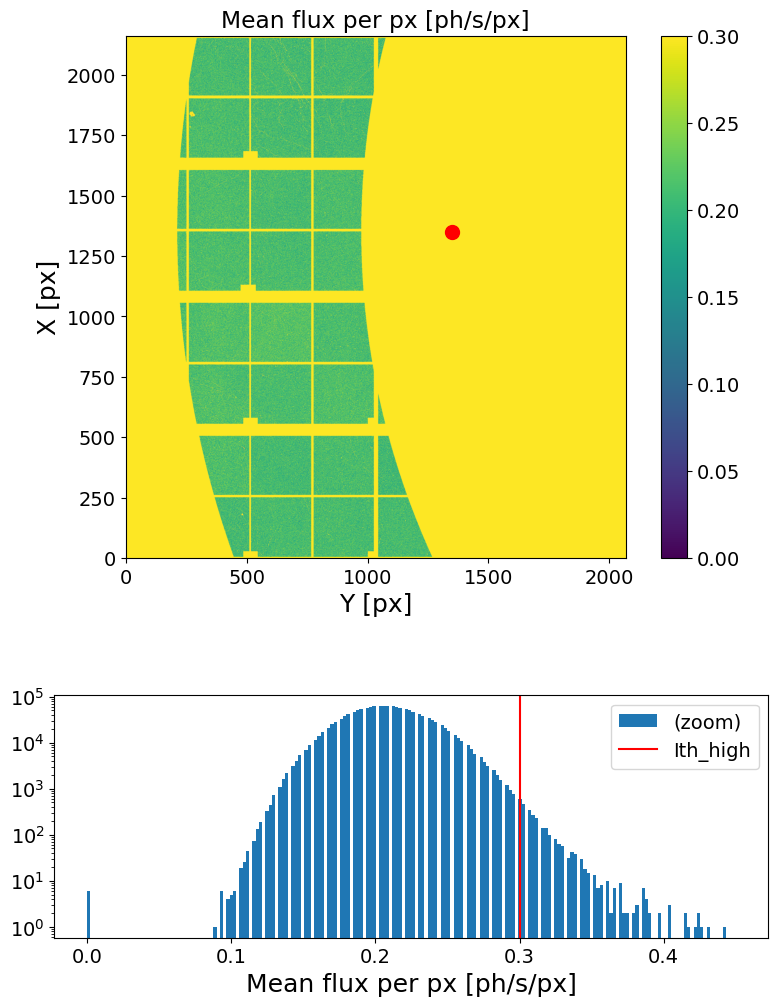

In [18]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.3, Nfi=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [19]:
####################
Lbin = 1
Nstep = 100
mask = None
####################

t_It, It = XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep)
np.savez(Idt_folder+'Idt_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_It=t_It, It=It)

<SecondaryAxis: >

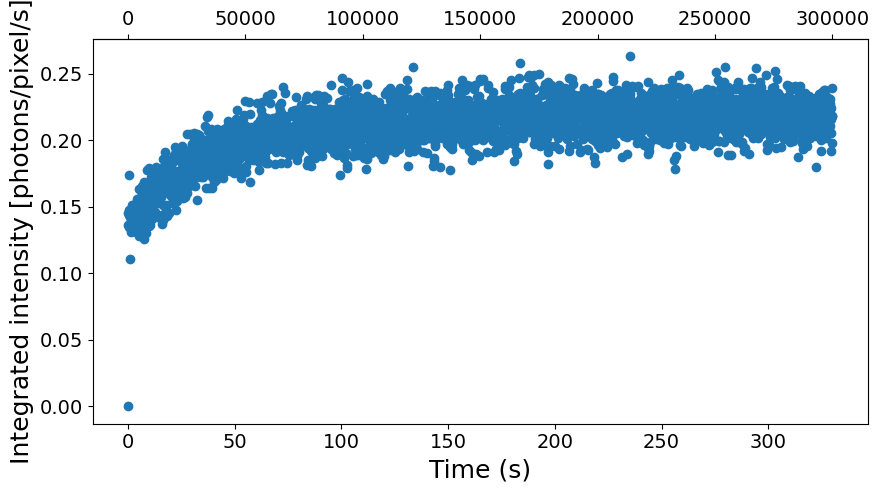

In [20]:
plt.figure(figsize=(10,5))
plt.scatter(t_It, It, label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
#plt.xlim(0,100)
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Correlation

In [21]:
XPCS.print_Nf_choices(num_frames)

       Nf = 300048    =>    log2(Nf) = 18.19
----------------------------------------------------
  reduced Nf  dense depth (2^x)  thrown frames %  thrown frames
0      2**18                 17             12.6          37904
1    9*2**15                 14              2.0           5136
2   73*2**12                 11              0.0           1040
3  293*2**10                  9              0.0             16
----------------------------------------------------


In [22]:
##### INPUTS #####
Nfi = 37_500
Nff = 37_500 + 2**18
sparse_depth = 11
dense_depth = 17
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, dense_depth=dense_depth, mask=mask, Nfi=Nfi, Nff=Nff)


Loading frames ...
Done! (elapsed time = 0.94 s)
	 | 262144 frames X 1427140 pixels
	 | sparsity = 2.35e-04
	 | memory usage (sparse.csr_array @ float32) = 0.985 GB
Computing sparse multitau G2t...


100%|██████████| 128/128 [00:09<00:00, 13.92it/s]


Done! (elapsed time = 9.22 s)
Computing dense multitau G2t...


100%|██████████| 6/6 [00:00<00:00, 16.33it/s]

Done! (elapsed time = 0.37 s)


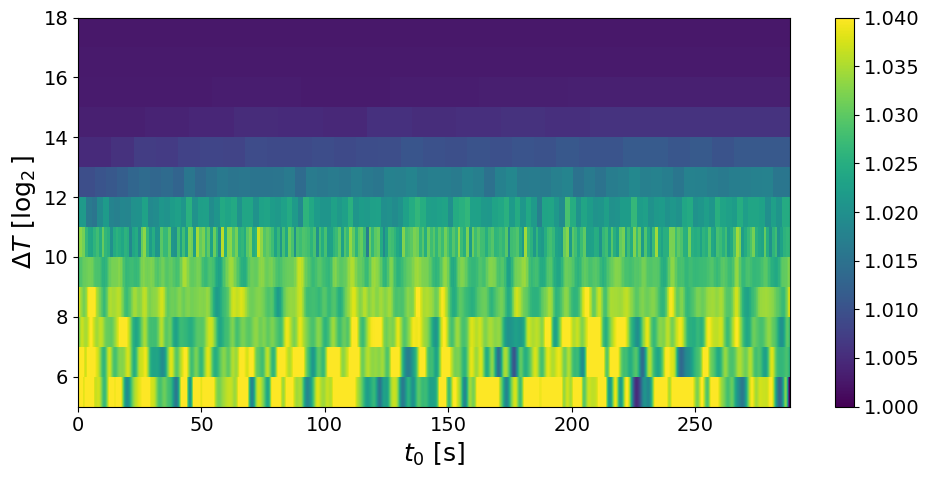

In [23]:
############################
vmin, vmax = 1.0, 1.04
lower_mt = 5
filter_layer = 10
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log2', lower_mt=lower_mt, filter_layer=filter_layer)

In [24]:
t_mt, g2_mt, dg2_mt = XPCS.get_g2mt(itime, G2tmt)

np.savez(g2_folder+'g2_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_mt=t_mt, g2_mt=g2_mt, dg2_mt=dg2_mt)

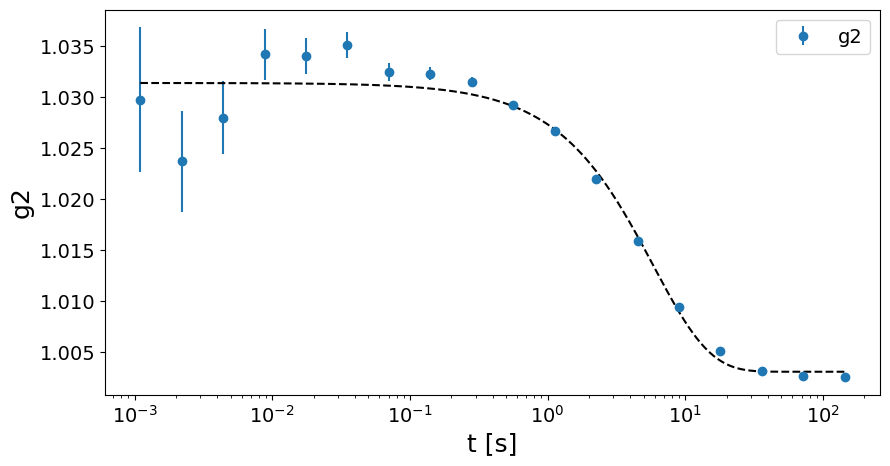

####### Fit parameters #######
tau = 5.8615 +/- 1.2368 s
beta = 1.0557 +/- 0.2651
c = 0.0283 +/- 0.0019
y0 = 1.0031 +/- 0.0016


In [25]:
plt.figure(figsize=(10,5))
fit_out = pd.DataFrame(columns=['tau', 'beta', 'c', 'y0', 'dtau', 'dbeta', 'dc', 'dy0'])
fit_out.index.name = 't'

plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt='o', label='g2')

popt, pcov = curve_fit(decorrelation_f, t_mt, g2_mt, sigma=None, p0=[3, .7, .02, 1], bounds=([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf])) # TO BOUND THE FIT: t1_fit, t2_fit = 0, 1e10,  t[k] ->  t[k][(t1_fit<t[k])*(t[k]<t2_fit)]; g2[k] ->  g2[k][(t1_fit<t[k])*(t[k]<t2_fit)]
fit_out.loc[G2tmt[0].size*itime/2] = [popt[0], popt[1], popt[2], popt[3], np.sqrt(pcov[0,0]), np.sqrt(pcov[1,1]), np.sqrt(pcov[2,2]), np.sqrt(pcov[3,3])]
fit_out.to_csv(fit_out_folder+'fit_out_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4)+'.csv')

X = np.arange(np.min(t_mt), np.max(t_mt), 1e-4)
Y = decorrelation_f(X, *popt)
plt.plot(X, Y, c='black', ls='--')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.legend()
plt.show()

print('####### Fit parameters #######')
print(f'tau = { round(popt[0],4)} +/- {round(np.sqrt(pcov[0,0]),4)} s')
print(f'beta = {round(popt[1],4)} +/- {round(np.sqrt(pcov[1,1]),4)}')
print(f'c = {   round(popt[2],4)} +/- {round(np.sqrt(pcov[2,2]),4)}')
print(f'y0 = {  round(popt[3],4)} +/- {round(np.sqrt(pcov[3,3]),4)}')

## XPCS scan (T = 30C Q =  0.19 Å, 25 min @ 1ms (1_500_000 fm)) (GeO2_3, dataset 1, scan 4)

In [26]:
#######################################
sample_name = 'GeO2_3_30C'
Ndataset = 1
Nscan = 4
Nfi, Nff =  None, None
load_mask = e4m_mask*e4m_htmask*bs_mask*Qmask
#######################################

scan = ID10.load_scan(raw_folder, sample_name, Ndataset, Nscan)
num_frames = scan['num frames']
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('number of frames =', num_frames)
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(raw_folder, sample_name, Ndataset, Nscan, Nfi, Nff, load_mask=load_mask, n_jobs=60, )
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=5)

#############################
command = mtimescan 0.001 1 1500240
number of frames = 1500240
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/301 loops)
	 -> loading file eiger4m_v2_sparse_fr

### Flux check

################################################################################
Maximum count in the hull run -> 5.0
# of pixels above Ith_high treshold ->  3044986 pixels (of 4471016 => 68.11 %)
################################################################################



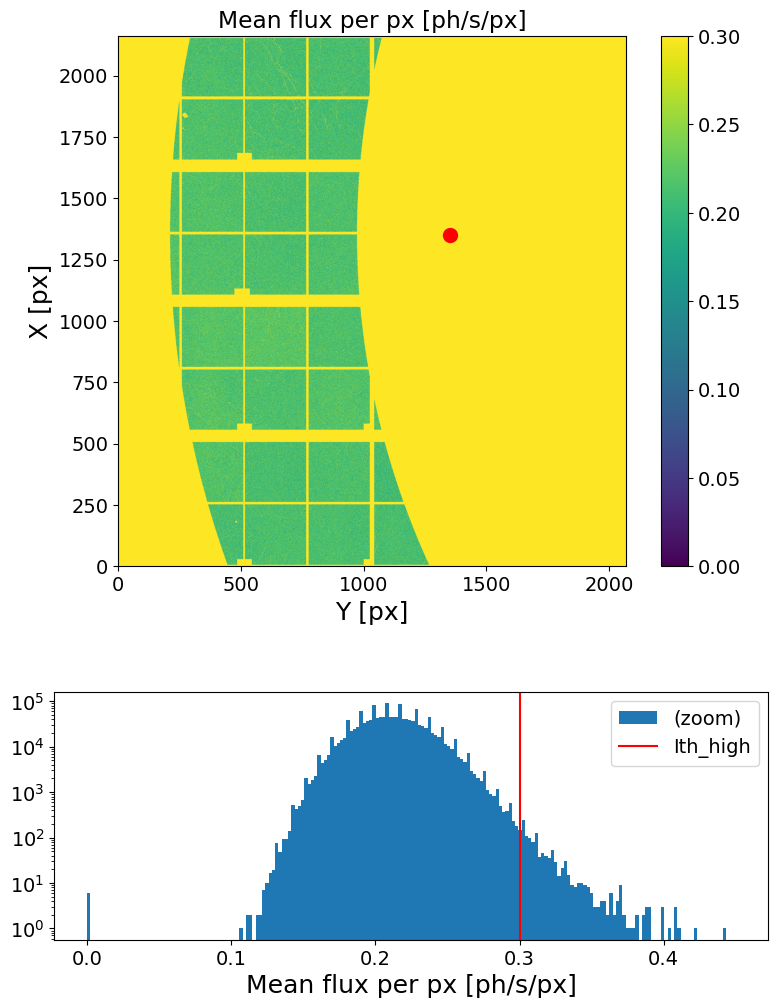

In [27]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.3, Nfi=int(1e6), Nff=int(1.5e6), load_mask=load_mask)

### Intensity analysis

In [28]:
####################
Lbin = 1
Nstep = 100
mask = None
####################

t_It, It = XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep)
np.savez(Idt_folder+'Idt_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_It=t_It, It=It)

<SecondaryAxis: >

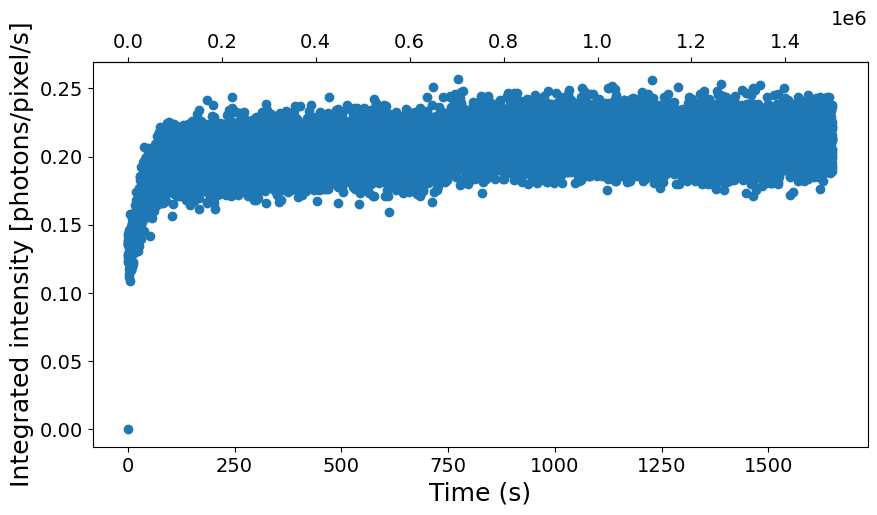

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(t_It, It, label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
#plt.xlim(0,250)
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Correlation

In [30]:
XPCS.print_Nf_choices(num_frames)

       Nf = 1500240    =>    log2(Nf) = 20.52
----------------------------------------------------
  reduced Nf  dense depth (2^x)  thrown frames %  thrown frames
0      2**20                 19             30.1         451664
1    5*2**18                 17             13.0         189520
2   11*2**17                 16              4.0          58448
3   45*2**15                 14              2.0          25680
4   91*2**14                 13              1.0           9296
5  183*2**13                 12              0.0           1104
----------------------------------------------------


In [31]:
##### INPUTS #####
Nfi = 100_000
Nff = 100_000 + 5*2**18
sparse_depth = 11
dense_depth = 17
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, dense_depth=dense_depth, mask=mask, Nfi=Nfi, Nff=Nff)


Loading frames ...
Done! (elapsed time = 5.02 s)
	 | 1310720 frames X 1427140 pixels
	 | sparsity = 2.29e-04
	 | memory usage (sparse.csr_array @ float32) = 4.788 GB
Computing sparse multitau G2t...


100%|██████████| 640/640 [00:58<00:00, 10.90it/s]


Done! (elapsed time = 58.71 s)
Computing dense multitau G2t...


100%|██████████| 6/6 [00:02<00:00,  2.79it/s]

Done! (elapsed time = 2.16 s)


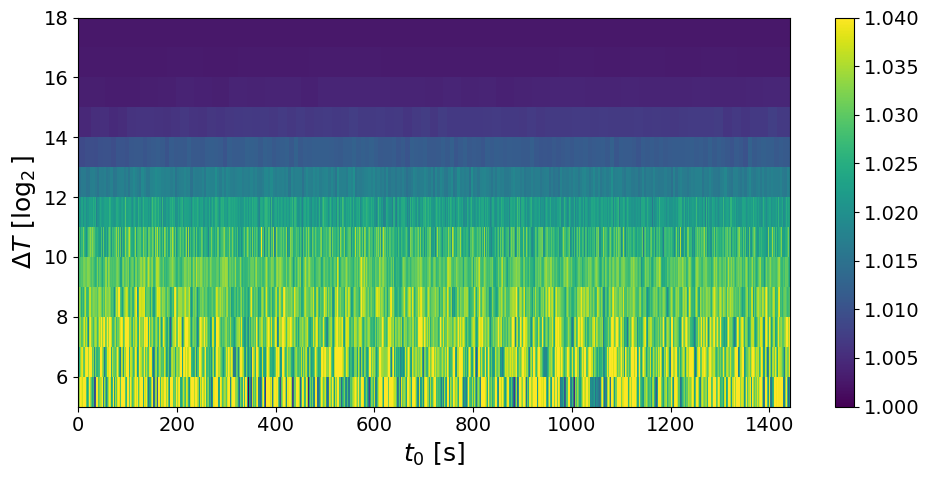

In [32]:
############################
vmin, vmax = 1.0, 1.04
lower_mt = 5
filter_layer = 10
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log2', lower_mt=lower_mt, filter_layer=filter_layer)

In [33]:
t_mt, g2_mt, dg2_mt = XPCS.get_g2mt(itime, G2tmt)

np.savez(g2_folder+'g2_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_mt=t_mt, g2_mt=g2_mt, dg2_mt=dg2_mt)

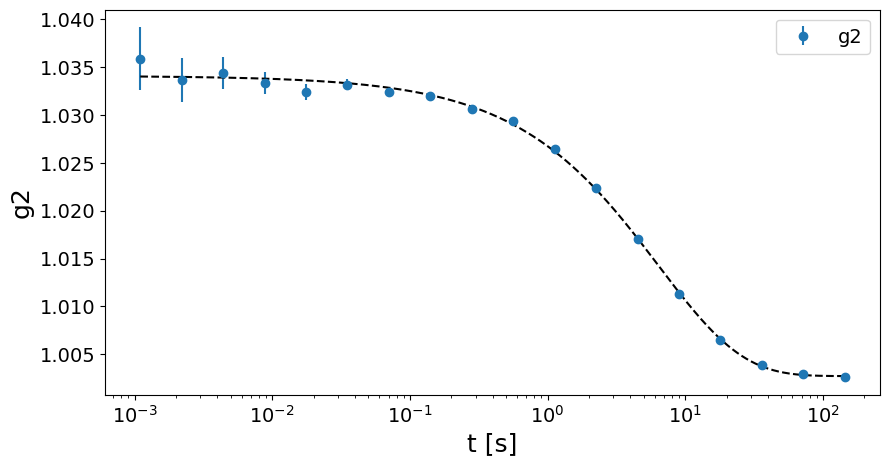

####### Fit parameters #######
tau = 6.3928 +/- 0.4076 s
beta = 0.7127 +/- 0.0362
c = 0.0314 +/- 0.0006
y0 = 1.0027 +/- 0.0004


In [34]:
plt.figure(figsize=(10,5))
fit_out = pd.DataFrame(columns=['tau', 'beta', 'c', 'y0', 'dtau', 'dbeta', 'dc', 'dy0'])
fit_out.index.name = 't'

plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt='o', label='g2')

popt, pcov = curve_fit(decorrelation_f, t_mt, g2_mt, sigma=None, p0=[3, .7, .02, 1], bounds=([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf])) # TO BOUND THE FIT: t1_fit, t2_fit = 0, 1e10,  t[k] ->  t[k][(t1_fit<t[k])*(t[k]<t2_fit)]; g2[k] ->  g2[k][(t1_fit<t[k])*(t[k]<t2_fit)]
fit_out.loc[G2tmt[0].size*itime/2] = [popt[0], popt[1], popt[2], popt[3], np.sqrt(pcov[0,0]), np.sqrt(pcov[1,1]), np.sqrt(pcov[2,2]), np.sqrt(pcov[3,3])]
fit_out.to_csv(fit_out_folder+'fit_out_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4)+'.csv')

X = np.arange(np.min(t_mt), np.max(t_mt), 1e-4)
Y = decorrelation_f(X, *popt)
plt.plot(X, Y, c='black', ls='--')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.legend()
plt.show()

print('####### Fit parameters #######')
print(f'tau = { round(popt[0],4)} +/- {round(np.sqrt(pcov[0,0]),4)} s')
print(f'beta = {round(popt[1],4)} +/- {round(np.sqrt(pcov[1,1]),4)}')
print(f'c = {   round(popt[2],4)} +/- {round(np.sqrt(pcov[2,2]),4)}')
print(f'y0 = {  round(popt[3],4)} +/- {round(np.sqrt(pcov[3,3]),4)}')

## XPCS scan (T = 100C Q =  0.19 Å, 25 min @ 1ms (1_500_000 fm)) (GeO2_3, dataset 1, scan 4)

In [35]:
#######################################
sample_name = 'GeO2_3_100C'
Ndataset = 1
Nscan = 4
Nfi, Nff =  None, None
load_mask = e4m_mask*e4m_htmask*bs_mask*Qmask
#######################################

scan = ID10.load_scan(raw_folder, sample_name, Ndataset, Nscan)
num_frames = scan['num frames']
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('number of frames =', num_frames)
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(raw_folder, sample_name, Ndataset, Nscan, Nfi, Nff, load_mask=load_mask, n_jobs=60, )
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=5)

#############################
command = mtimescan 0.001 1 1500240
number of frames = 1500240
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/301 loops)
	 -> loading file eiger4m_v2_sparse_fr

### Flux check

################################################################################
Maximum count in the hull run -> 5.0
# of pixels above Ith_high treshold ->  3044187 pixels (of 4471016 => 68.09 %)
################################################################################



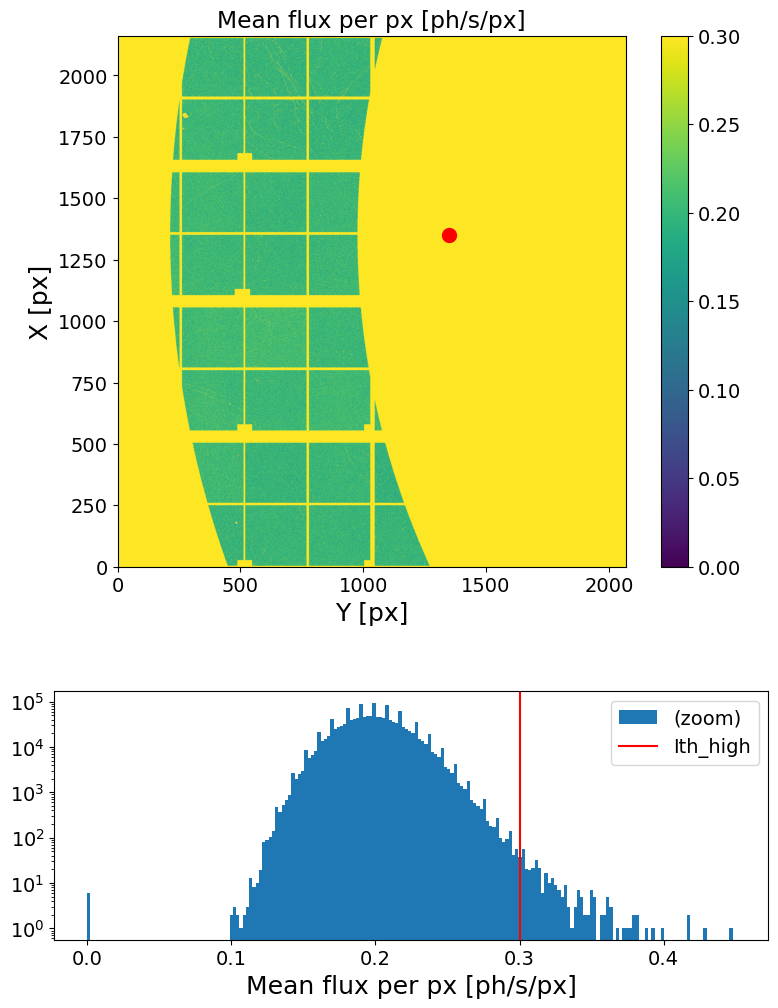

In [36]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.3, Nfi=int(1e6), Nff=int(1.5e6), load_mask=load_mask)

### Intensity analysis

In [37]:
####################
Lbin = 1
Nstep = 100
mask = None
####################

t_It, It = XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep)
np.savez(Idt_folder+'Idt_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_It=t_It, It=It)

<SecondaryAxis: >

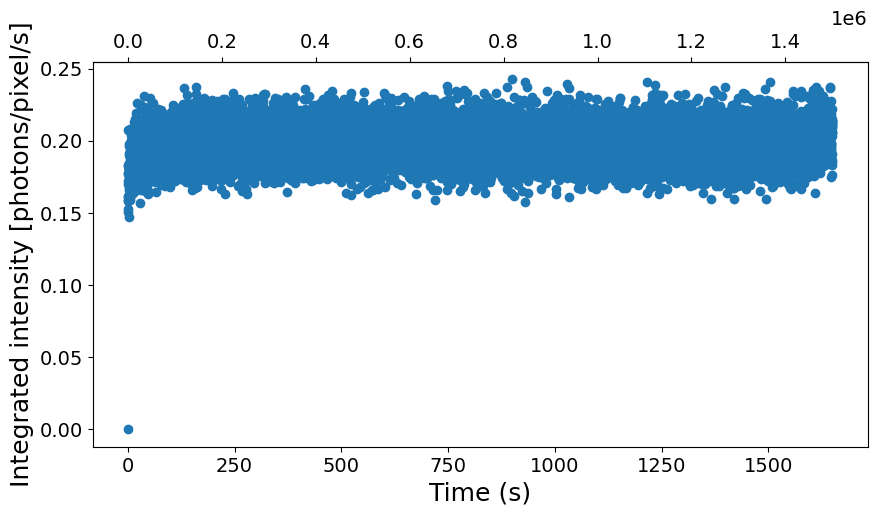

In [38]:
plt.figure(figsize=(10,5))
plt.scatter(t_It, It, label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
#plt.xlim(0,250)
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Correlation

In [39]:
XPCS.print_Nf_choices(num_frames)

       Nf = 1500240    =>    log2(Nf) = 20.52
----------------------------------------------------
  reduced Nf  dense depth (2^x)  thrown frames %  thrown frames
0      2**20                 19             30.1         451664
1    5*2**18                 17             13.0         189520
2   11*2**17                 16              4.0          58448
3   45*2**15                 14              2.0          25680
4   91*2**14                 13              1.0           9296
5  183*2**13                 12              0.0           1104
----------------------------------------------------


In [40]:
##### INPUTS #####
Nfi = 100_000
Nff = 100_000 + 5*2**18
sparse_depth = 11
dense_depth = 17
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, dense_depth=dense_depth, mask=mask, Nfi=Nfi, Nff=Nff)


Loading frames ...
Done! (elapsed time = 5.95 s)
	 | 1310720 frames X 1427140 pixels
	 | sparsity = 2.18e-04
	 | memory usage (sparse.csr_array @ float32) = 4.572 GB
Computing sparse multitau G2t...


100%|██████████| 640/640 [00:56<00:00, 11.36it/s]


Done! (elapsed time = 56.33 s)
Computing dense multitau G2t...


100%|██████████| 6/6 [00:01<00:00,  3.02it/s]

Done! (elapsed time = 1.99 s)


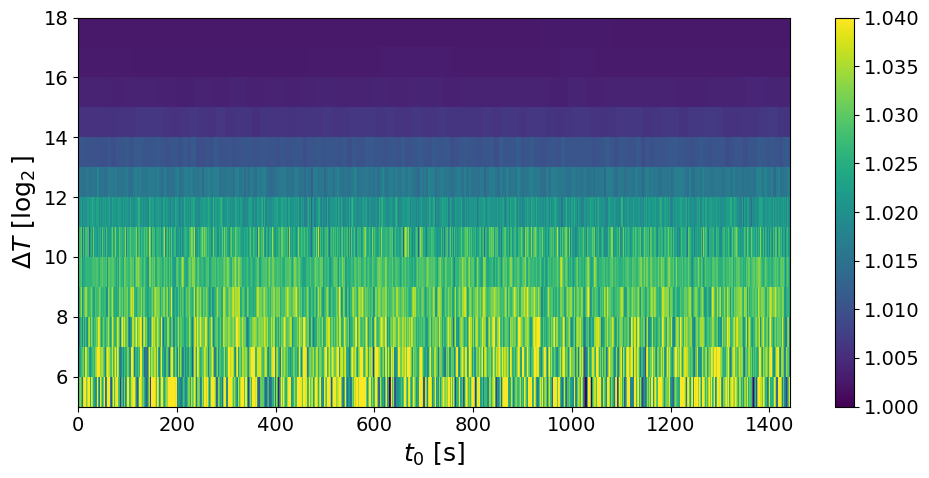

In [41]:
############################
vmin, vmax = 1.0, 1.04
lower_mt = 5
filter_layer = 10
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log2', lower_mt=lower_mt, filter_layer=filter_layer)

In [42]:
t_mt, g2_mt, dg2_mt = XPCS.get_g2mt(itime, G2tmt)

np.savez(g2_folder+'g2_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4), t_mt=t_mt, g2_mt=g2_mt, dg2_mt=dg2_mt)

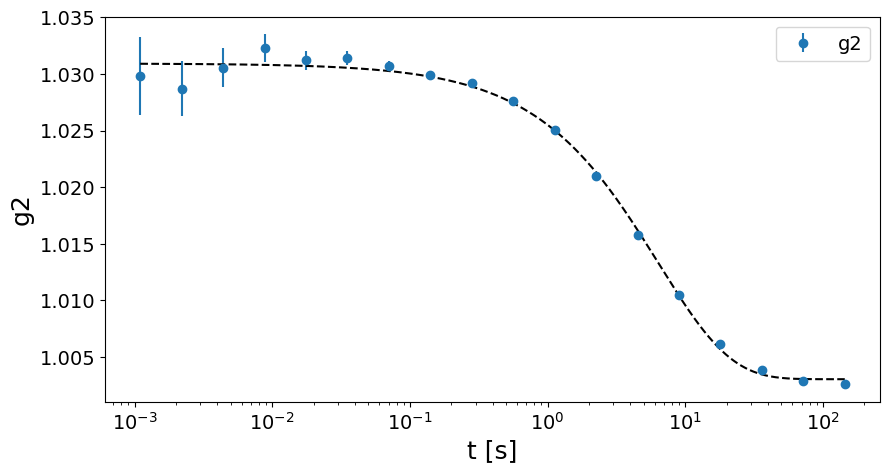

####### Fit parameters #######
tau = 6.377 +/- 0.5169 s
beta = 0.8273 +/- 0.0619
c = 0.0279 +/- 0.0007
y0 = 1.003 +/- 0.0005


In [43]:
plt.figure(figsize=(10,5))
fit_out = pd.DataFrame(columns=['tau', 'beta', 'c', 'y0', 'dtau', 'dbeta', 'dc', 'dy0'])
fit_out.index.name = 't'

plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt='o', label='g2')

popt, pcov = curve_fit(decorrelation_f, t_mt, g2_mt, sigma=None, p0=[3, .7, .02, 1], bounds=([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf])) # TO BOUND THE FIT: t1_fit, t2_fit = 0, 1e10,  t[k] ->  t[k][(t1_fit<t[k])*(t[k]<t2_fit)]; g2[k] ->  g2[k][(t1_fit<t[k])*(t[k]<t2_fit)]
fit_out.loc[G2tmt[0].size*itime/2] = [popt[0], popt[1], popt[2], popt[3], np.sqrt(pcov[0,0]), np.sqrt(pcov[1,1]), np.sqrt(pcov[2,2]), np.sqrt(pcov[3,3])]
fit_out.to_csv(fit_out_folder+'fit_out_'+sample_name+'_'+str(Ndataset).zfill(4)+'_'+str(Nscan).zfill(4)+'.csv')

X = np.arange(np.min(t_mt), np.max(t_mt), 1e-4)
Y = decorrelation_f(X, *popt)
plt.plot(X, Y, c='black', ls='--')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.legend()
plt.show()

print('####### Fit parameters #######')
print(f'tau = { round(popt[0],4)} +/- {round(np.sqrt(pcov[0,0]),4)} s')
print(f'beta = {round(popt[1],4)} +/- {round(np.sqrt(pcov[1,1]),4)}')
print(f'c = {   round(popt[2],4)} +/- {round(np.sqrt(pcov[2,2]),4)}')
print(f'y0 = {  round(popt[3],4)} +/- {round(np.sqrt(pcov[3,3]),4)}')